## Synthetic Dataset Analysis

This notebook serves the purpose of exploring and analyzing the synthetic patient scenario dataset after labelling, and prior to validation. The analysis includes Exploratory Data Analysis, as well as inter-rater agreement.

In [122]:
#Import all libraries necessary to run the analysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

### 1.Inter-rater Agreement Analysis

This section analyzes the disagreement between the healthcare professionals involved in labelling, as well as assigning the final outcome labels for the synthetic dataset based on majority votes. Each healthcare professional was given the same dataset, structured in the same format and order, to label independently. Clinicians were asked to read through the different patient details included within the dataset, and label each patient scenario within a categorical, 3 level risk range: Low risk/Medium risk/High risk, considering the risk of the patient having opioid toxicity.

In [123]:
#Import all labelled datasets
clinician1 = pd.read_csv("dataset_c1.csv")
clinician2 = pd.read_csv("dataset_c2.csv")
clinician3 = pd.read_csv("dataset_c3.csv")

In [124]:
#Create a dataframe aggregating all outcome labels across the 3 datasets
clinician_labels = pd.DataFrame({
    "patient_ID": clinician1["patient_ID"],
    "C1": clinician1["Outcome"],
    "C2": clinician2["Outcome"],
    "C3": clinician3["Outcome"]
})

display(clinician_labels.head())

,patient_ID,C1,C2,C3
0,ID_654,High,Medium,High
1,ID_233,High,Medium,Medium
2,ID_135,High,High,High
3,ID_209,Low,Medium,Low
4,ID_830,High,High,High


#### 1.1 Fleiss' Kappa

Fleiss' Kappa is used as a metric to calculate the agreement between healthcare professionals, as it supports analysis of multiple annotators. 

In [125]:
#Drop PatientID to ensure data is just risk level labels
raw_labels = clinician_labels.drop("patient_ID", axis=1)

#Convert raw risk level labels into a count table
table, categories = aggregate_raters(raw_labels)

# Calculate Fleiss' kappa
kappa = fleiss_kappa(table, method="fleiss")
print(f"Fleiss' Kappa score is: {kappa}")

Fleiss' Kappa score is: 0.7856933968586644


The result shows a Fleiss' Kappa of 0.79. This score falls at the higher end of "Substantial Agreement" range, as defined within the following scale:
1. 0.0-0.20 Slight
2. 0.21-0.40 Fair
3. 0.41-0.60 Moderate
4. 0.61-0.80 Substantial
5. 0.81-1.00 Almost perfect

The score suggests substantial consensus among annotators and a reliable labelling process. 

#### 1.2 Pattern Analysis

To better understand where disagreement occurred, patterns within labelling differences are analyzed. Specifically, agreement counts are collected to identify how many cases are defined by full, partial or no agreement. Additionally, partial or no agreement cases are analyzed across risk levels and features, to identify where most differences occurred. 

In [126]:
#Analyze overall agreement levels across the full dataset. 

# Count the unique labels assigned per patient scenario by each clinician
clinician_labels["unique_labels"] = clinician_labels[["C1","C2","C3"]].nunique(axis=1)

#Define agreement scale
clinician_labels["agreement_levels"] = clinician_labels["unique_labels"].map({
    1: "Full agreement", #All clinicians provided the same label
    2: "Partial agreement", #Two out of the three clinicians provided the same label
    3: "No agreement" #All of the labels are different
})
print(clinician_labels["agreement_levels"].value_counts())

agreement_levels
Full agreement       283
Partial agreement     67
Name: count, dtype: int64


In [127]:
#Analyze agreement rate per risk level (outcome) label
print("\nAgreement rate across risk level labels:")

#Identify how often clinicians agree per label
for label in ['Low', 'Medium', 'High']:
    subset = clinician_labels[clinician_labels[['C1', 'C2', 'C3']].eq(label).any(axis=1)]
    
#Count rows where clinicians fully agreed
    full = (subset["agreement_levels"] == "Full agreement").sum()
    print(f"  {label}: {full}/{len(subset)} full agreement ({full/len(subset)*100:.1f}%)")


Agreement rate across risk level labels:
  Low: 57/73 full agreement (78.1%)
  Medium: 62/126 full agreement (49.2%)
  High: 164/218 full agreement (75.2%)


In [128]:
#Analyze agreement across features

#Drop outcome feature and include all core features representing symptoms, risk factors and vitals
features = clinician1.drop(columns=["Outcome"])
full_data = clinician_labels.merge(features, on="patient_ID")

#Define core features
#Note: Symptom features that are active only if symptom is present are not included, as they are considered conditional and not core features
symptoms = ['TWC-000','HAL-000','DRW-000','SED-000','SLS-000','AGT-000','CON-000','DIZ-000','VOM-000','NAU-000','PPL-000','COD-000','CYN-000']
risk_factors = ['REN-000','LIV-000','SAP-000','LNG-000','MED-ANX-000','MED-APS-000','MED-STM-000','MED-REC-000','MED-OPD-001','MED-OPD-002','MED-OPD-003','INF-000','ALC-000','HST-OPX-000']
vitals = ['OXG-000','RSP-000','BPM-000']

#Define function to count agreement per feature where feature is present ("Yes")
def feature_agreement(column, value="Yes"):
    feature = full_data[full_data[column] == value]
    agreed = (feature["agreement_levels"] == "Full agreement").sum()
    total = len(feature)
    print(f"  {column:<20} {agreed}/{total} agreed ({agreed/total*100:.1f}%)")

print("Symptoms")
for col in symptoms:
    feature_agreement(col)

print("\nRisk Factors")
for col in risk_factors:
    feature_agreement(col)
feature_agreement("AGE-000", value="65 or Above")

print("\nVitals (above/below threshold)")
#Define thresholds of vitals to replace using all the different measurements
thresholds = [('OXG-000',  '<',  94),('RSP-000',  '<',  12),('RSP-000',  '>',  25),('BPM-000',  '<',  50)]
for col, operator, threshold in thresholds:
    feature = full_data[full_data[col] < threshold]
    agreed = (feature["agreement_levels"] == "Full agreement").sum()
    total = len(feature)
    if total > 0:
        print(f"  {col}<{threshold:<18} {agreed}/{total} agreed ({agreed/total*100:.1f}%)")

Symptoms
  TWC-000              76/99 agreed (76.8%)
  HAL-000              59/66 agreed (89.4%)
  DRW-000              136/172 agreed (79.1%)
  SED-000              83/101 agreed (82.2%)
  SLS-000              102/115 agreed (88.7%)
  AGT-000              81/98 agreed (82.7%)
  CON-000              148/176 agreed (84.1%)
  DIZ-000              90/105 agreed (85.7%)
  VOM-000              43/54 agreed (79.6%)
  NAU-000              47/57 agreed (82.5%)
  PPL-000              36/45 agreed (80.0%)
  COD-000              45/56 agreed (80.4%)
  CYN-000              41/54 agreed (75.9%)

Risk Factors
  REN-000              38/47 agreed (80.9%)
  LIV-000              38/46 agreed (82.6%)
  SAP-000              45/57 agreed (78.9%)
  LNG-000              51/64 agreed (79.7%)
  MED-ANX-000          53/60 agreed (88.3%)
  MED-APS-000          34/40 agreed (85.0%)
  MED-STM-000          38/42 agreed (90.5%)
  MED-REC-000          34/45 agreed (75.6%)
  MED-OPD-001          21/26 agreed (80.8%)
 

The analysis of trends across agreement and disagreement reveals strong agreement across all health professionals involved in the labelling, with only 67 cases reflecting partial agreement. Further, no full disagreement is identified, where labels across all experts are completely different, showing that in all cases reflecting differences a consensus is present among 2 out of the 3 clinicians. 

In terms of agreement rate across risk levels, healthcare professionals demonstrated high full agreement for patient scenarios labelled as low risk, followed closely by high risk scenarios. Agreement for medium risk cases, however, is limited, barely reaching 50%. This trend suggests the complexity of labelling medium cases, compared to low or high risk scenarios which are more clear and obvious due to non-presence of specific features. 

When analyzed across each feature, agreement across all healthcare professionals is very strong, all reaching a percentage of over 70%. This suggests that most of the time, clinicians viewed the risk level or score of each independent feature similarly. 

### 2. Majority Vote Analysis

This section covers the majority vote analysis. Since disagreement between clinicians was discovered, each patient scenario where labels differ must be revised, and a consensus label must be determined for each record. The method applied for this case is majority voting: for each patient where labels different, the final label is decided through consensus, choosing the outcome assigned by 2 out of the 3 clinicians involved. A majority label can be determined for each patient scenario, as no full disagreement was identified in the prior analysis. 

In [129]:
#Define function to calculate the majority vote and identify patient scenarios where a majority vote does not exist

#Count labels for each row and select the most common
def label_outcome(row):
    labels = [row["C1"], row["C2"], row["C3"]]
    counts = Counter(labels)
    common_label, common_count = counts.most_common(1)[0]
    if common_count >= 2:
        return common_label
#Define patient records where no common label is identified
    else:
        return "MV not found"

#Apply the new risk level identified through consensus
clinician_labels["MV"] = clinician_labels.apply(label_outcome, axis=1)
display(clinician_labels.head())

#Identify cases with no majority votes
no_MV = clinician_labels[clinician_labels["MV"] == "MV not found"]
print(f"Cases needing discussion: {len(no_MV)}")

,patient_ID,C1,C2,C3,unique_labels,agreement_levels,MV
0,ID_654,High,Medium,High,2,Partial agreement,High
1,ID_233,High,Medium,Medium,2,Partial agreement,Medium
2,ID_135,High,High,High,1,Full agreement,High
3,ID_209,Low,Medium,Low,2,Partial agreement,Low
4,ID_830,High,High,High,1,Full agreement,High


Cases needing discussion: 0


In [130]:
# Create a copy of the original dataset
final_df = clinician1.copy()

# Replace risk level outcome with majority vote
final_df["Outcome"] = clinician_labels["MV"]

display(final_df.head())

,patient_ID,TWC-000,TWC-001,TWC-002,TWC-003,TWC-004,HAL-000,HAL-001,HAL-002,HAL-003,...,MED-OPD-001,MED-OPD-002,MED-OPD-002-1,MED-OPD-003,ALC-000,HST-OPX-000,INF-000,AGE-000,Patient_Summary,Outcome
0,ID_654,Yes,New symptom,At unpredictable times,Trembling,Legs or feet,No,not_asked,not_asked,not_asked,...,No,No,not_asked,No,No,No,No,Below 65,The patient is reporting: Twitching (Symptom E...,High
1,ID_233,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,No,not_asked,Yes,No,No,No,Below 65,The patient is reporting: Dizziness (Symptom E...,Medium
2,ID_135,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,No,No,No,No,Below 65,The patient is reporting: Sedation (Symptom Ev...,High
3,ID_209,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,No,No,No,No,Below 65,The patient is reporting: Drowsiness (Symptom ...,Low
4,ID_830,Yes,Same as usual,After physical activity,Trembling,Face,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,Yes,No,No,No,Below 65,The patient is reporting: Twitching (Symptom E...,High


In [131]:
# Save dataframe to Excel
final_df.to_csv("MV_dataset.csv", index=False)

### 3. Exploratory Data Analysis (EDA)

This section includes an exploratory data analysis (EDA) of the synthetic dataset, for the purpose of better understanding the features, class balance, distribution and inter-feature associations. 

The EDA includes feature distribution bar charts and box plots to visualize outcome (risk level) balance and feature variation across each risk level assigned, and Cramer's V to quantify the association between categorical features and the risk levels acting as outcomes. 


In [132]:
df= pd.read_csv("MV_dataset.csv")

#### 3.1 Distribution of Outcome (Risk Levels)

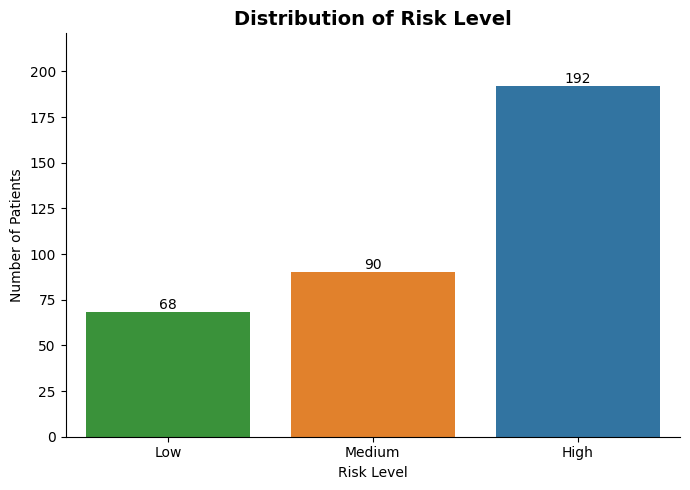

In [133]:
#Define figure
fig, ax = plt.subplots(figsize=(7, 5))

#Define the order of the risk levels, from low to high
order = ['Low', 'Medium', 'High']

sns.countplot(data=df, x='Outcome', hue='Outcome',
              order=order, legend=False, ax=ax)

#Add count at the top of the bars for each risk category
for container in ax.containers:
    ax.bar_label(container)

#Set plot details
ax.set_title('Distribution of Risk Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, df['Outcome'].value_counts().max() * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

The dataset contains 350 patient scenarios divided across three risk levels, defined as the outcome feature. The distribution of outcomes across the full dataset reflects a high imbalance, with more than half of the dataset containing high risk patient records. In comparison, scenarios labelled as low or medium risk are seen at lower levels.  

#### 3.2 Feature Level Analysis

C:\Users\maria\AppData\Local\Temp\ipykernel_21672\2203220996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Outcome',y='Symptom Count', order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'])


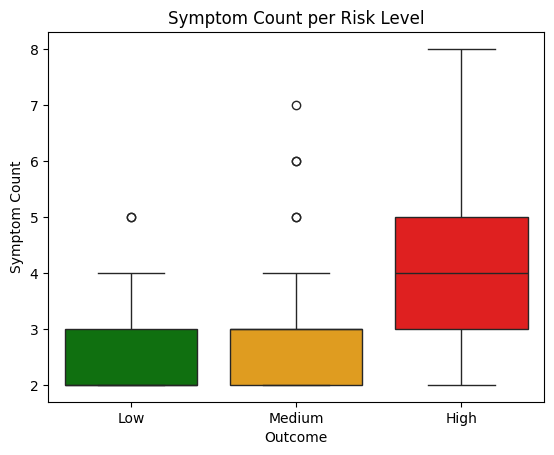

In [134]:
#Analyze number of symptoms per patient record across risk levels
#Note: Symptom features that are active only if symptom is present are not included, as they are considered conditional and not core features
symptoms = ['TWC-000','HAL-000','DRW-000','SED-000','SLS-000','AGT-000','CON-000','DIZ-000','VOM-000','NAU-000','PPL-000','COD-000','CYN-000']

#Count how many symptoms are "Yes"
df['Symptom Count'] = (df[symptoms] == 'Yes').sum(axis=1)

#Create boxplot
sns.boxplot(data=df,x='Outcome',y='Symptom Count', order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'])
plt.title('Symptom Count per Risk Level')
plt.savefig('symptom_count.pdf', bbox_inches='tight')
plt.show()

This visualization represents how the symptom count is distributed across patient records for every risk. Patients at high risk have a significantly higher symptom count or burden, with most experiencing between 3 and 5 symptoms. The interquartile range  within the high risk scenarios further suggests greater variability in symptom presentation, compared to low or medium patient records which sit between 2 to 4 symptoms. The visualization suggests a trend where patients labelled at higher risk of opioid toxicity are represented by scenarios with more symptoms.

C:\Users\maria\AppData\Local\Temp\ipykernel_21672\301022890.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Outcome',y='Risk Factor Count', order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'])


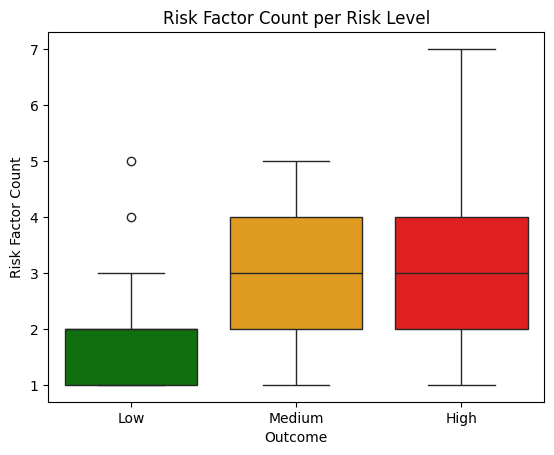

In [135]:
#Analyze number of risk factors per patient record across risk levels
risk_factors = ['REN-000','LIV-000','SAP-000','LNG-000','MED-ANX-000','MED-APS-000','MED-STM-000','MED-REC-000','MED-OPD-001','MED-OPD-002','MED-OPD-003','INF-000','ALC-000','HST-OPX-000']

#Count how many risk factors are "Yes"
df['Risk Factor Count'] = (df[risk_factors] == 'Yes').sum(axis=1)

#Count age based on risk threshold (65 or above)
df['Risk Factor Count'] += (df['AGE-000'] == '65 or Above')

#Create boxplot
sns.boxplot(data=df,x='Outcome',y='Risk Factor Count', order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'])
plt.title('Risk Factor Count per Risk Level')
plt.savefig('rf_count.pdf', bbox_inches='tight')
plt.show()

The visualization represents how the number of risk factor is distributed across risk levels. Patient records assigned with a medium and high risk label have an increased number of risk factors, with most values ranging from 2 to 4 factors per patient, with an upper range as high as 7 risk factors. In comparison, patients presenting a low risk have a significantly lower number of risk factors per case, with a range of 1 to 2. This pattern suggests a trend across the number of risk factors present per risk levels, with risk increasing as patients show more of these risk factors.

C:\Users\maria\AppData\Local\Temp\ipykernel_21672\3633123070.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Outcome',y=df["OXG-000"], order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'],ax=axes[0])
C:\Users\maria\AppData\Local\Temp\ipykernel_21672\3633123070.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Outcome',y=df["RSP-000"], order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'],ax=axes[1])
C:\Users\maria\AppData\Local\Temp\ipykernel_21672\3633123070.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

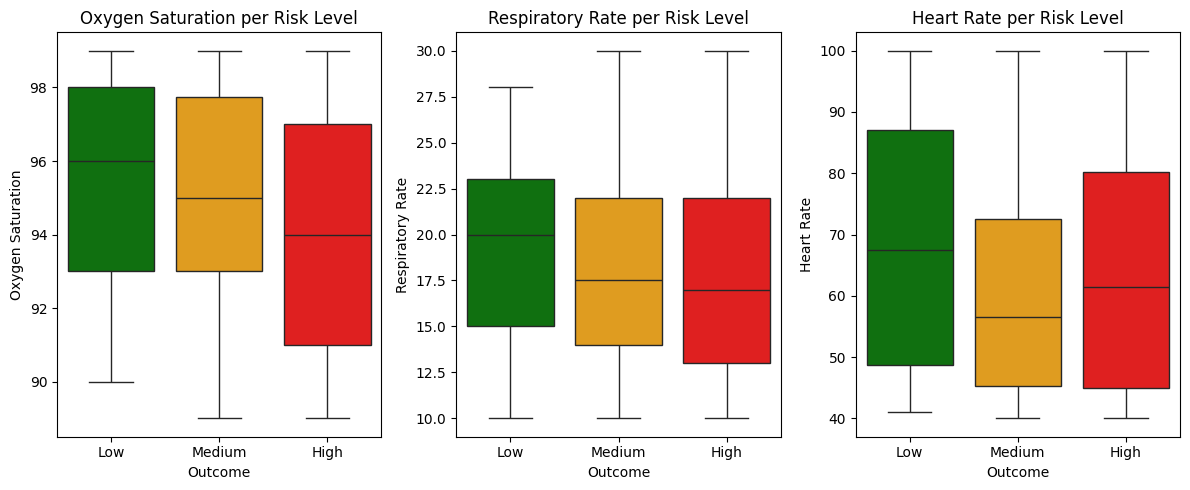

In [136]:
#Analyze vital measurement across all 3 vitals per patient record across risk levels

#Define subplots
fig,axes = plt.subplots(1,3, figsize=(12,5))

#Define boxplot for oxygen saturation
sns.boxplot(data=df,x='Outcome',y=df["OXG-000"], order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'],ax=axes[0])
axes[0].set_title('Oxygen Saturation per Risk Level')
axes[0].set_ylabel('Oxygen Saturation')

#Define boxplot for respiratory rate
sns.boxplot(data=df,x='Outcome',y=df["RSP-000"], order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'],ax=axes[1])
axes[1].set_title('Respiratory Rate per Risk Level')
axes[1].set_ylabel('Respiratory Rate')

#Define boxplot for heart rate
sns.boxplot(data=df,x='Outcome',y=df["BPM-000"], order=["Low", "Medium", "High"], palette=['green', 'orange', 'red'],ax=axes[2])
axes[2].set_title('Heart Rate per Risk Level')
axes[2].set_ylabel('Heart Rate')

plt.tight_layout()
plt.savefig('vital_count.pdf', bbox_inches='tight')
plt.show()

The visualization of vital signs across risk level shows a limited separation between risk groups. For example, oxygen saturation appears to slightly decrease for patients characterized as high risk, with a median of 94% saturation. In comparison, low risk records have a median of 94%. Although the groups remain within a similar range, this pattern reflects that a lower oxygen saturation increases risk level. A similar trend can be observed across respiratory rate, where high risk cases are presented with a median of 17.5, while low risk patient scenarios show a median of 20.0 breaths per minute. This pattern is reflected across heart rate measurements as well, where medium risk patient scenarios have a lower median than high risk, although all outcome levels are within the same range. Overall, the analysis of vital measurements across risk levels shows weak patterns where risk increases with lower measurements, indicating that additional clinical indicators such as symptoms and risk factors are necessary to determine the risk level of a patient.

#### 3.3 Cramer's V Analysis - Feature Association Analysis

Cramer's V is computed to measure the strength of association between the categorical features and the outcome variable, which is defined by the 3 risk levels. The measurement lies between 0 and 1, with 1 showing a strong association between two variables. To better understand associations, the computation of Cramer's V includes a visualization of the top ranked features associated with the outcome. 

In [137]:

def cramers_v(x, y):
    #Create a contingency table
    contingency_table = pd.crosstab(x, y)
    chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
    
    #Calculate Cramer's V
    n = contingency_table.sum().sum()
    phi2 = chi2_statistic / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corr = k - (k - 1) * (k - 2) / (n - 1)
    r_corr = r - (r - 1) * (r - 2) / (n - 1)
    v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
    
    return v

In [138]:
#Exclude all non-categorical and numerical columns
exclude = ['patient_ID', 'Patient_Summary', 'OXG-000', 'RSP-000', 'BPM-000']

#Additionally exclude conditional features defined only when symptoms are present
core_features = symptoms + risk_factors + ['AGE-000']
cat_variables = [col for col in df.columns if (col in core_features or col == 'Outcome') and col not in exclude]

#Create dataframe to store results
cramers_v_matrix = pd.DataFrame(index=cat_variables, columns=cat_variables)

#Calculate Cramér's V for each core feature pair
for var1 in cat_variables:
    for var2 in cat_variables:
        cramers_v_matrix.loc[var1, var2] = cramers_v(df[var1], df[var2])

print(cramers_v_matrix)

              TWC-000   HAL-000   DRW-000   SED-000   SLS-000   AGT-000  \
TWC-000      0.991514  0.031552       0.0       0.0       0.0       0.0   
HAL-000      0.031552  0.989216       0.0   0.04786       0.0       0.0   
DRW-000           0.0       0.0  0.992842  0.036451       0.0       0.0   
SED-000           0.0   0.04786  0.036451  0.991598       0.0       0.0   
SLS-000           0.0       0.0       0.0       0.0  0.992081       0.0   
AGT-000           0.0       0.0       0.0       0.0       0.0   0.99147   
CON-000      0.059069       0.0       0.0  0.039791       0.0       0.0   
DIZ-000           0.0       0.0   0.08567  0.038694       0.0       0.0   
VOM-000           0.0       0.0  0.079109       0.0       0.0       0.0   
NAU-000           0.0       0.0       0.0       0.0       0.0       0.0   
PPL-000      0.059642   0.06855  0.099441   0.06539   0.02646       0.0   
COD-000           0.0       0.0       0.0  0.033134  0.081966       0.0   
CYN-000           0.0    

In [139]:
#Define dictionary to replace feature codes with names - Core symptoms and Risk Factors
feature_names = {
    'TWC-000': 'Twitching',
    'HAL-000': 'Hallucinations',
    'DRW-000': 'Drowsiness',
    'SED-000': 'Sedation',
    'SLS-000': 'Slurred Speech',
    'AGT-000': 'Agitation',
    'CON-000': 'Confusion',
    'DIZ-000': 'Dizziness',
    'VOM-000': 'Vomiting',
    'NAU-000': 'Nausea',
    'PPL-000': 'Pinpoint Pupils',
    'COD-000': 'Incoordination',
    'CYN-000': 'Cyanosis',
    'REN-000': 'Renal Impairment',
    'LIV-000': 'Liver Impairment',
    'SAP-000': 'Sleep Apnea',
    'LNG-000': 'Chronic Obstructive Pulmonary Disease',
    'MED-ANX-000': 'Antidepressant drug therapy',
    'MED-APS-000': 'Antipsychotic drug therapy',
    'MED-STM-000': 'Stimulant drug therapy',
    'MED-REC-000': 'Recreational drug use',
    'MED-OPD-001': 'Opioid treatment naive',
    'MED-OPD-002': 'Opioid medication increase',
    'MED-OPD-003': 'Change of brand or formula in opioids',
    'ALC-000': 'Alcohol disorder',
    'HST-OPX-000': 'History of repeated overdose',
    'INF-000': 'Infection',
    'AGE-000': 'Age',
}

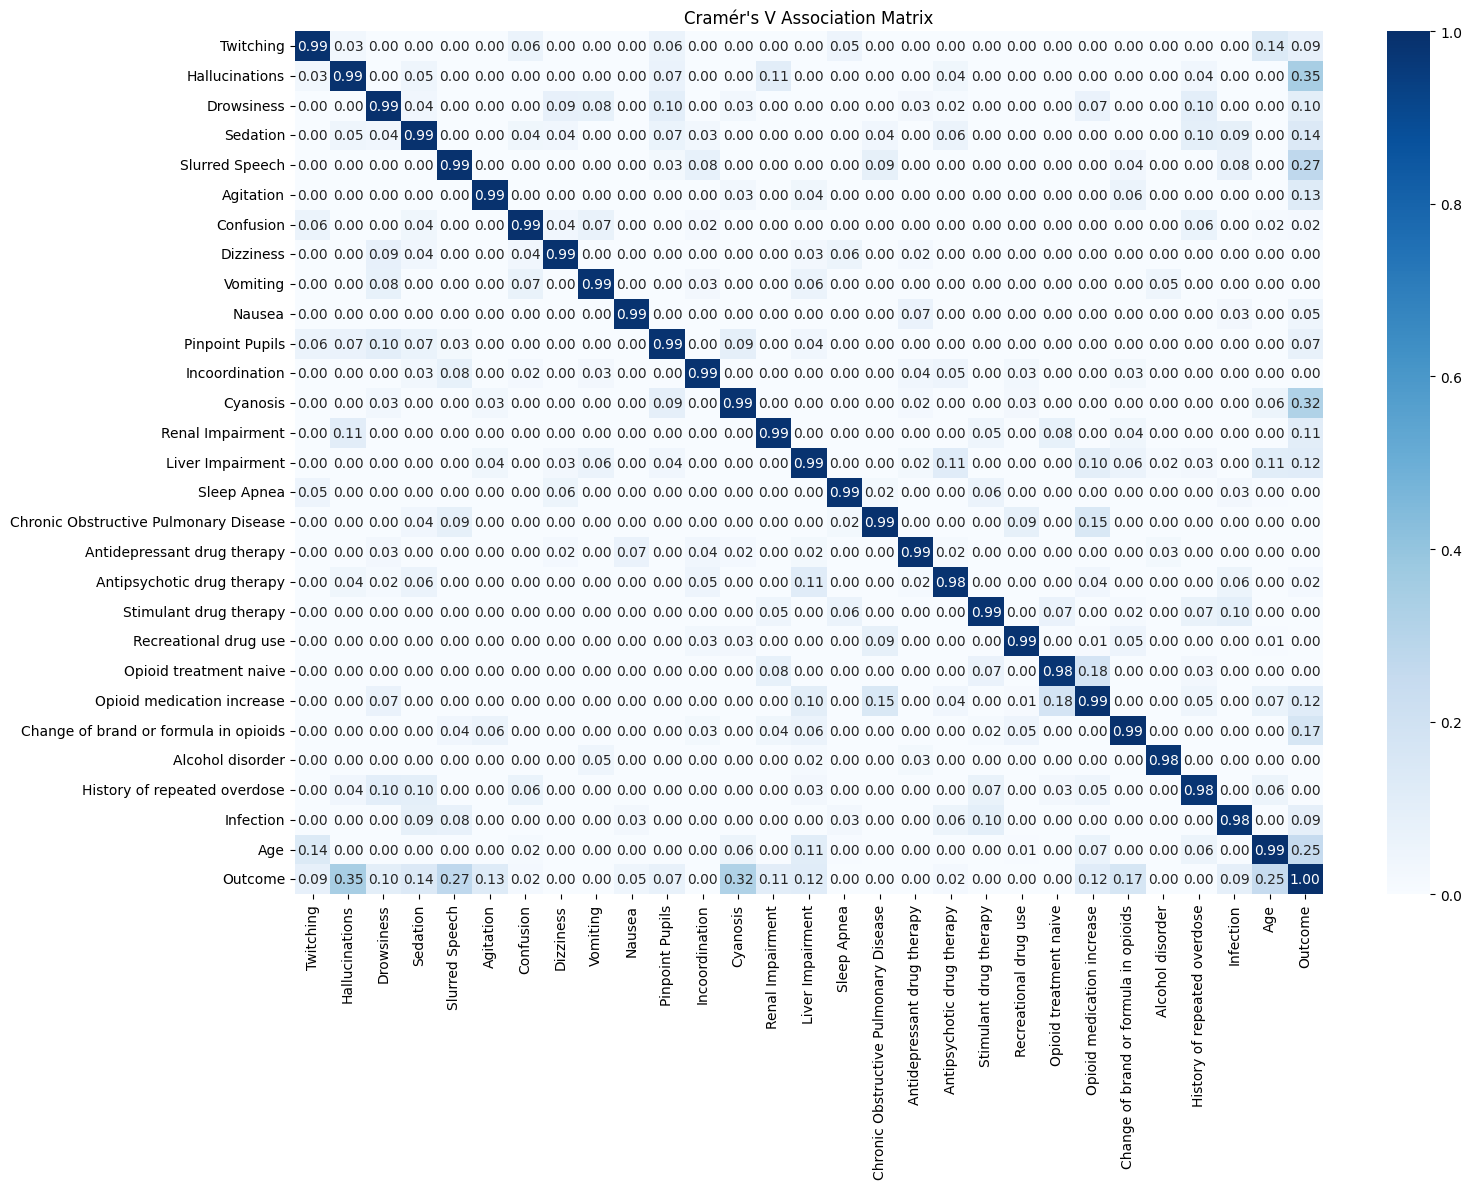

In [140]:
#Define heatmap figure
fig, ax = plt.subplots(figsize=(16, 12))
labels = [feature_names.get(col, col) for col in cat_variables]
sns.heatmap(cramers_v_matrix.astype(float), cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, ax=ax)

#Define axis and labels
ax.set_xticks(np.arange(len(labels)) + 0.5)
ax.set_yticks(np.arange(len(labels)) + 0.5)
ax.set_xticklabels(labels, rotation=90, ha='center')
ax.set_yticklabels(labels, va='center')

ax.set_title("Cramér's V Association Matrix")
plt.tight_layout()
plt.savefig('cramer_matrix.pdf', bbox_inches='tight')
plt.show()

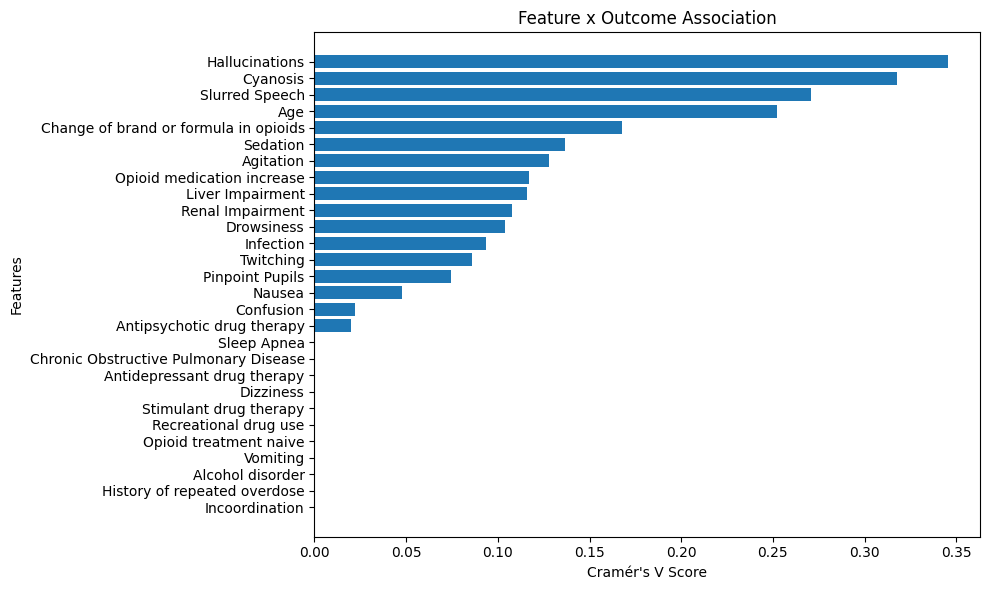

In [141]:
#Visualize only association between core features and outcomes

#Drop outcome from matrix
outcome_assoc = cramers_v_matrix['Outcome'].drop('Outcome')

#Sort values by highest Cramer's V value
outcome_assoc = outcome_assoc.sort_values(ascending=False)

#Define and show bar plot
labels = [feature_names.get(col, col) for col in outcome_assoc.index]
plt.figure(figsize=(10, 6))
plt.barh(labels, outcome_assoc.values)
plt.xlabel("Cramér's V Score")
plt.ylabel("Features")
plt.title("Feature x Outcome Association")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('cramer_analysis.pdf', bbox_inches='tight')
plt.show()

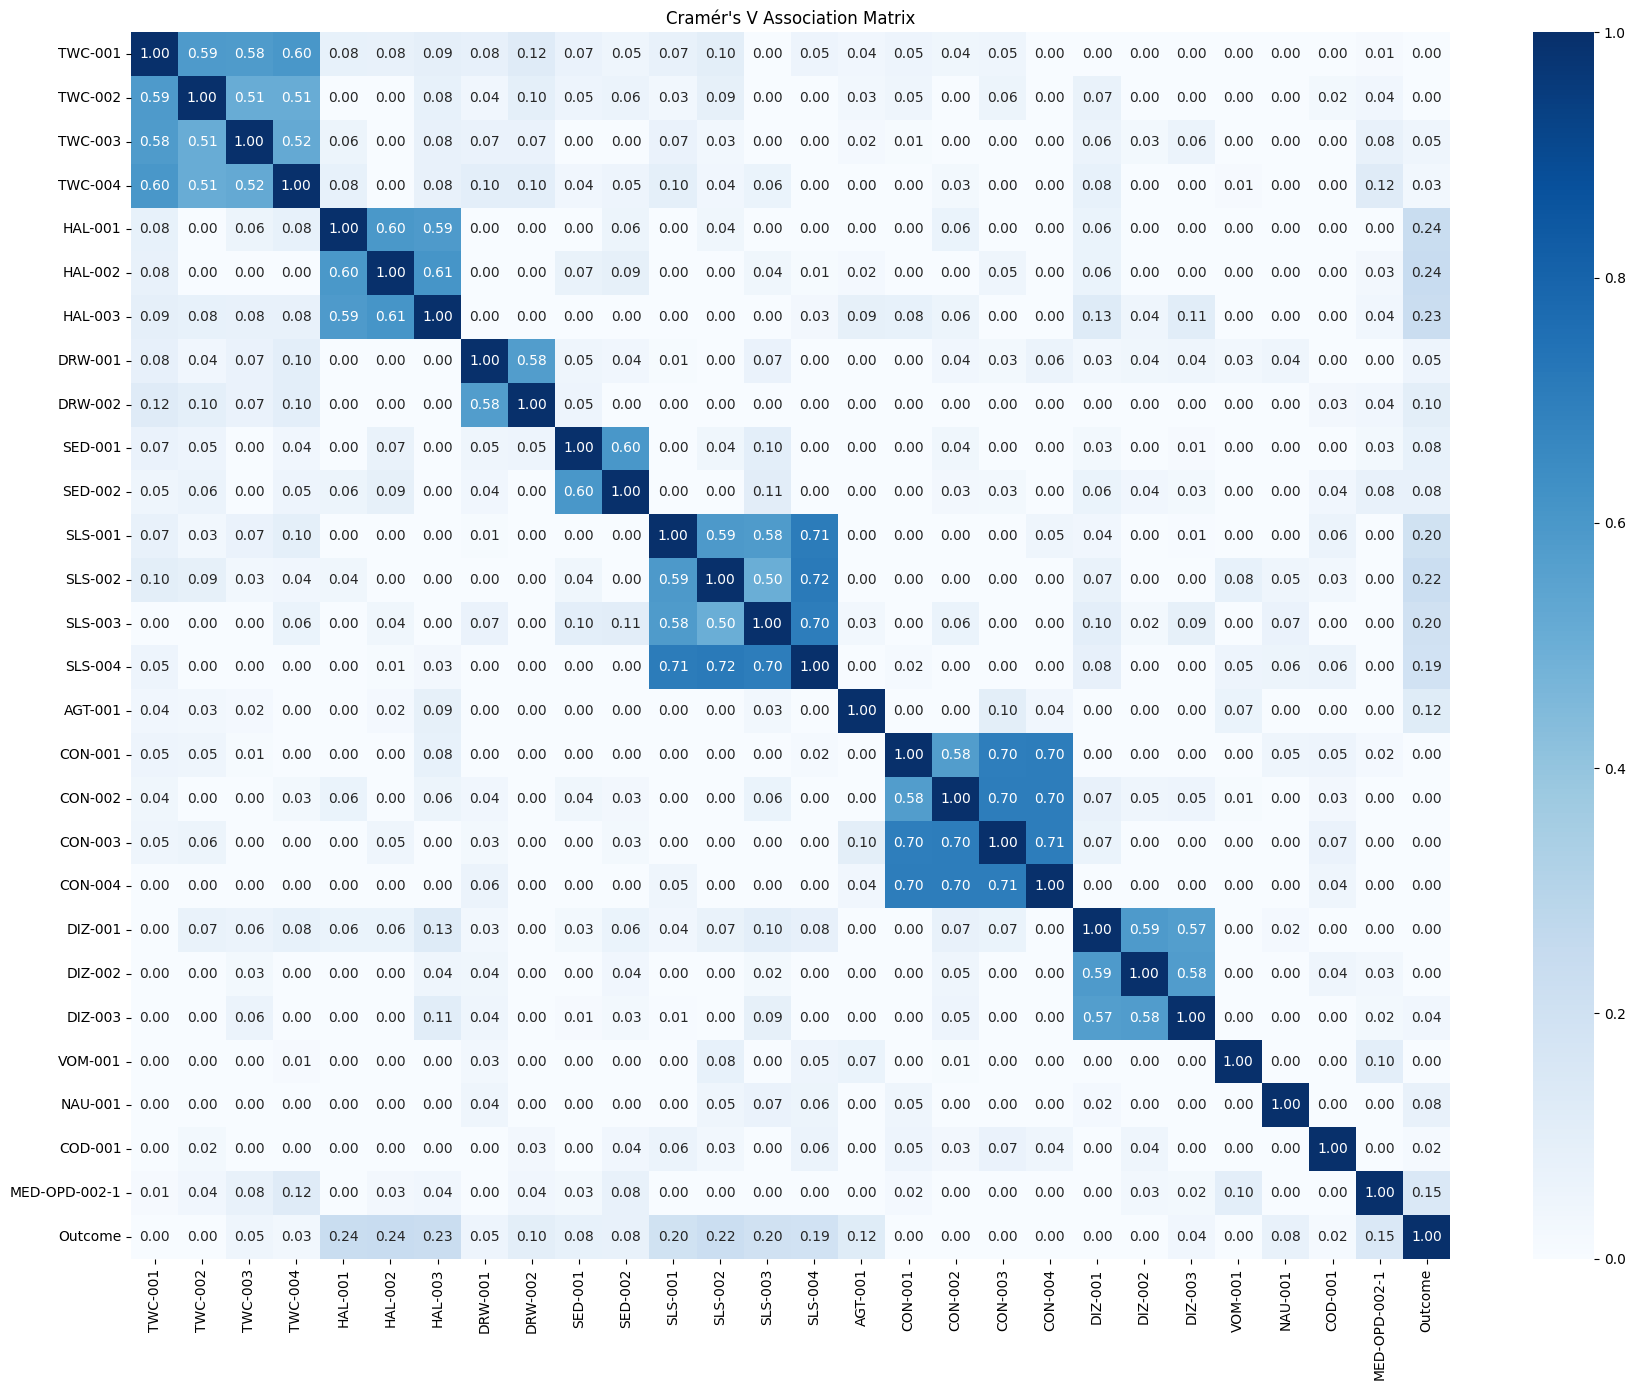

In [142]:
#Visualize association of conditional features and outcome

#Exclude patient id and summaries, vital measurements, outcome and all core symptoms and risk factors
exclude = ['patient_ID', 'Patient_Summary', 'OXG-000', 'RSP-000', 'BPM-000', 'Symptom Count', 'Risk Factor Count'] + list(feature_names.keys())
conditional_variables = [col for col in df.columns if col not in exclude]

#Create dataframe to store results
cramers_v_cond = pd.DataFrame(index=conditional_variables, columns=conditional_variables)

#Calculate Cramér's V for each conditional feature pair
for var1 in conditional_variables:
    for var2 in conditional_variables:
        cramers_v_cond.loc[var1, var2] = cramers_v(df[var1], df[var2])

conditional_labels = [feature_names.get(col, col) for col in conditional_variables]
#Define heatmap figure
fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(cramers_v_cond.astype(float), cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f', xticklabels=conditional_labels, yticklabels=conditional_labels, ax=ax)

ax.set_title("Cramér's V Association Matrix")
plt.tight_layout()
plt.savefig('cramer_matrix_conditional.pdf', bbox_inches='tight')
plt.show()

Cramer's V was computed and analyzed across pairs between all features. Two matrices were developed to ensure readability, one presenting the core features against the outcome, and the second presenting the conditional features (including the granular symptom and risk factor assessments) with the outcome. This first matrix reveals the core features as largely independent from each other. While some features may show an association, no pair showed a relationship that produced a score higher than 0.15 with the exception of two features: opioid treatment naive and opioid medication increase. This association reflects a constraint that was built-in during the generation rather than a clinical pattern. The core features were further examined in connection to the risk levels defined as outcomes, which revealed slightly stronger associations, although all below 0.50. Hallucinations is shown as the symptom with the strongest association to risk level, with a Cramer's V of 0.35, closely followed by Cyanosis (0.32) and Slurred Speech (0.27) and Age (0.25). With the relatively low associations illustrated, the analysis suggests that risk classification within the dataset is driven by a small group of clinical symptoms and factors rather than a broad range of core features. The second matrix reveals similar trends, where conditional questions regarding Hallucinations and Slurred Speech are shown to have a stronger association compared to the other conditional features. Further, strong cluster associations can be observed within the groups of conditional features which are connected to the same core feature. 

#### 3.4 Spearman Correlation - Numerical Feature Analysis

Spearman Correlation is computed to measure the strength of correlation between the continuous numerical features of the dataset, specifically oxygen saturation, heart rate and respiratory rate, and the outcome variable. Similar to Cramer's V association analysis, the measurement lies between 0 and 1, with 1 showing a strong correlation between two variables. 

In [143]:
#Define feature names for plot mapping
feature_names = {
    'OXG-000': 'Oxygen Saturation',
    'RSP-000' : 'Respiratory Rate',
    'BPM-000': 'Heart Rate'
}

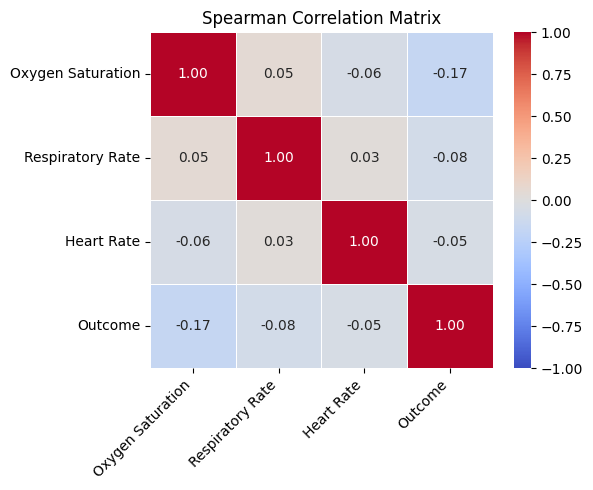

In [144]:
#Read dataset
df = pd.read_csv("MV_dataset.csv")

#Encode categorical outcome
encoder = LabelEncoder()
order_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
outcome_encoded = encoder.fit_transform(df["Outcome"].map(order_mapping))

#Create dataframe with vitals and outcome columns
vitals = ["OXG-000", "RSP-000", "BPM-000"]
spearman_df = df[vitals].copy()
spearman_df["Outcome"] = outcome_encoded

#Compute Spearman Correlation
corr = spearman_df.corr(method="spearman")

#Define and print plot
plt.figure(figsize=(6, 5))
labels = [feature_names.get(col, col) for col in spearman_df]
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5, xticklabels=labels, yticklabels=labels)
plt.title("Spearman Correlation Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('spearman_analysis.pdf', bbox_inches='tight')
plt.show()

The Spearman Correlation Matrix reveals no strong correlations between the vital features and outcome, suggesting they behave mostly independently and the values of a vital feature does not have a significant influence over the risk level assigned as outcome. Upon analysis, all vital measurements have a weak, negative correlation with the outcome. This indicates that a lower vital measurement increases risk. When compared, Oxygen Saturation is seen to have a significantly higher correlation to the outcome (ρ=-0.17) compared to Respiratory Rate (ρ=-0.08) and Heart Rate (ρ=-0.05). Although the correlation values are weak, their negative direction reflect a pattern commonly described in opioid toxicity, suggesting that decline in vitals can show higher risk of the complication.